<a href="https://colab.research.google.com/github/amenidhawadi/heart/blob/public/notb1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cellule 1: Installation et import des bibliothèques
!pip install pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Configuration du style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliothèques importées avec succès!")

Bibliothèques importées avec succès!


In [3]:
# Cellule 2: Chargement du dataset depuis GitHub (ou upload local)
# Option 1: Depuis un fichier uploadé manuellement
from google.colab import files
uploaded = files.upload()

# Option 2: Depuis une URL (si vous avez mis le fichier sur GitHub)
# url = "https://raw.githubusercontent.com/VOTRE_USERNAME/Heart-Disease-Prediction/main/data/heart.csv"
# df = pd.read_csv(url)

# Ici on suppose que vous avez uploadé le fichier
import io
df = pd.read_csv(io.BytesIO(uploaded['heart.csv']))

print("Dataset chargé. Shape:", df.shape)
df.head()

Saving heart.csv to heart.csv
Dataset chargé. Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Cellule 3: Informations générales sur le dataset
print("=== Informations générales ===")
df.info()

print("\n=== Statistiques descriptives ===")
df.describe()

print("\n=== Valeurs manquantes ===")
df.isnull().sum()

print("\n=== Doublons ===")
print(f"Nombre de doublons: {df.duplicated().sum()}")

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

=== Statistiques descriptives ===

=== Valeurs manquantes ===

=== Doublons ===
Nombre de doublons: 0


=== Distribution de la variable cible ===
HeartDisease
1    508
0    410
Name: count, dtype: int64

Pourcentage:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


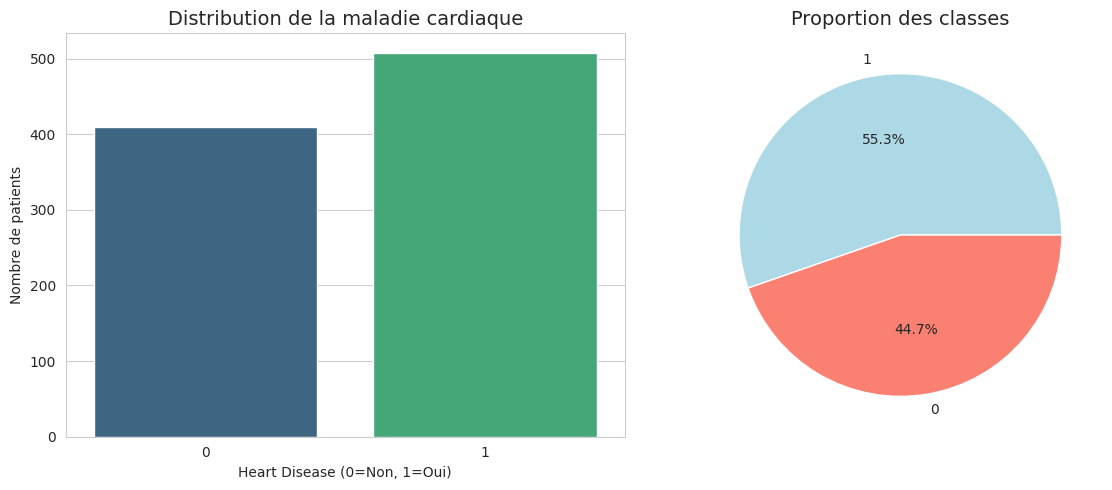

In [5]:
# Cellule 4: Analyse de la variable cible (HeartDisease)
print("=== Distribution de la variable cible ===")
print(df['HeartDisease'].value_counts())
print(f"\nPourcentage:\n{df['HeartDisease'].value_counts(normalize=True) * 100}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Comptage
sns.countplot(data=df, x='HeartDisease', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution de la maladie cardiaque', fontsize=14)
axes[0].set_xlabel('Heart Disease (0=Non, 1=Oui)')
axes[0].set_ylabel('Nombre de patients')

# Pie chart
df['HeartDisease'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['lightblue', 'salmon'])
axes[1].set_title('Proportion des classes', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

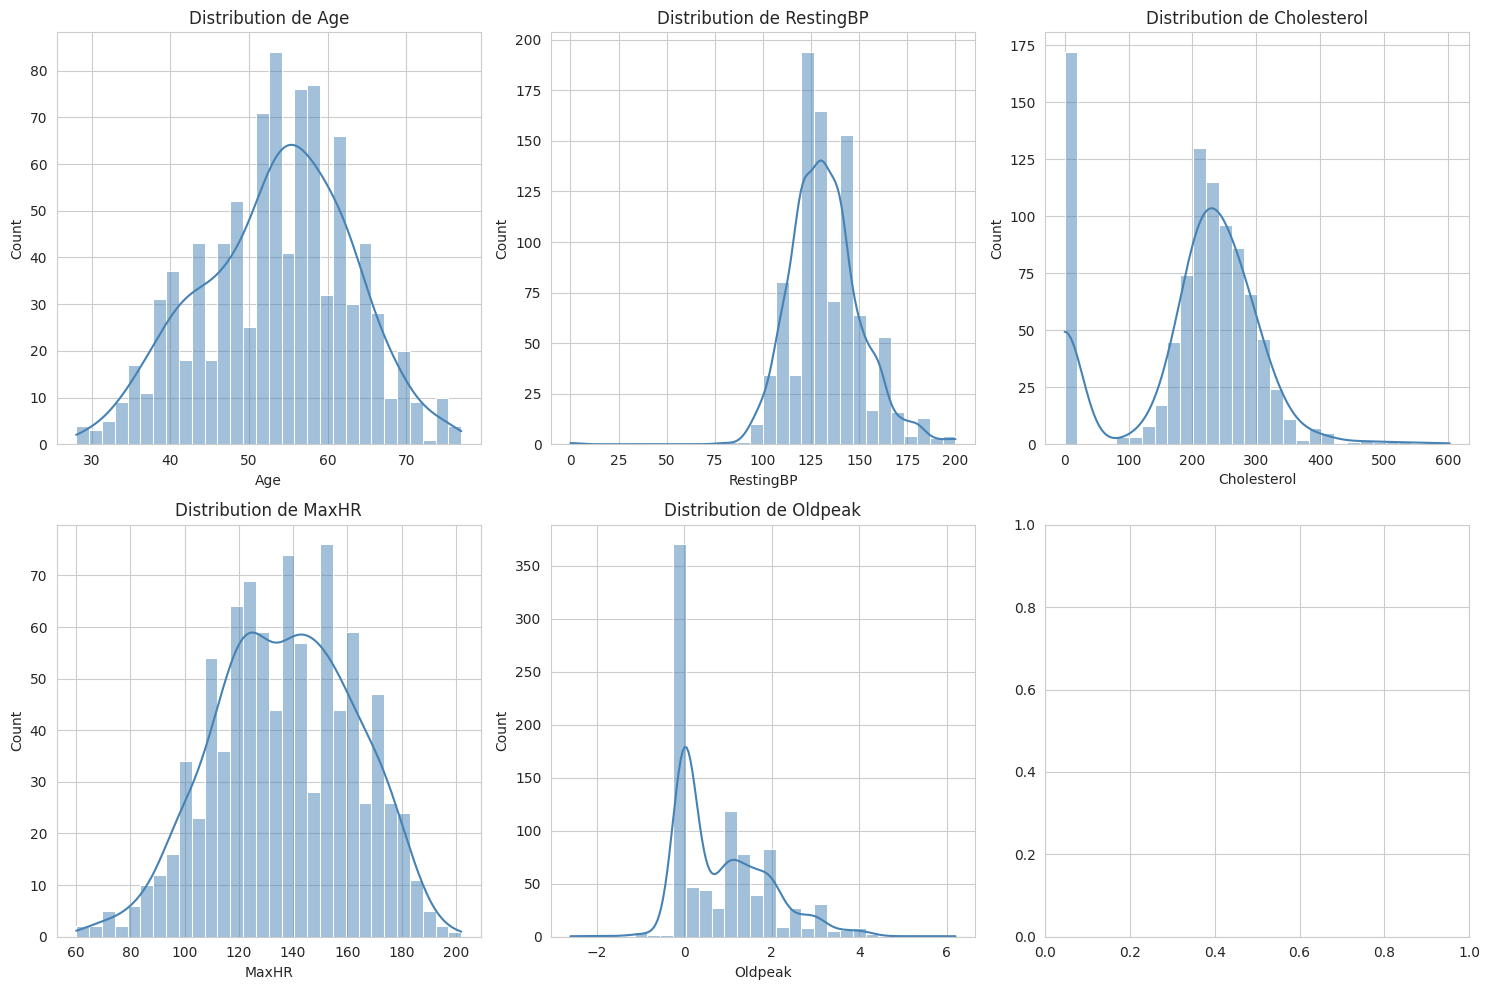

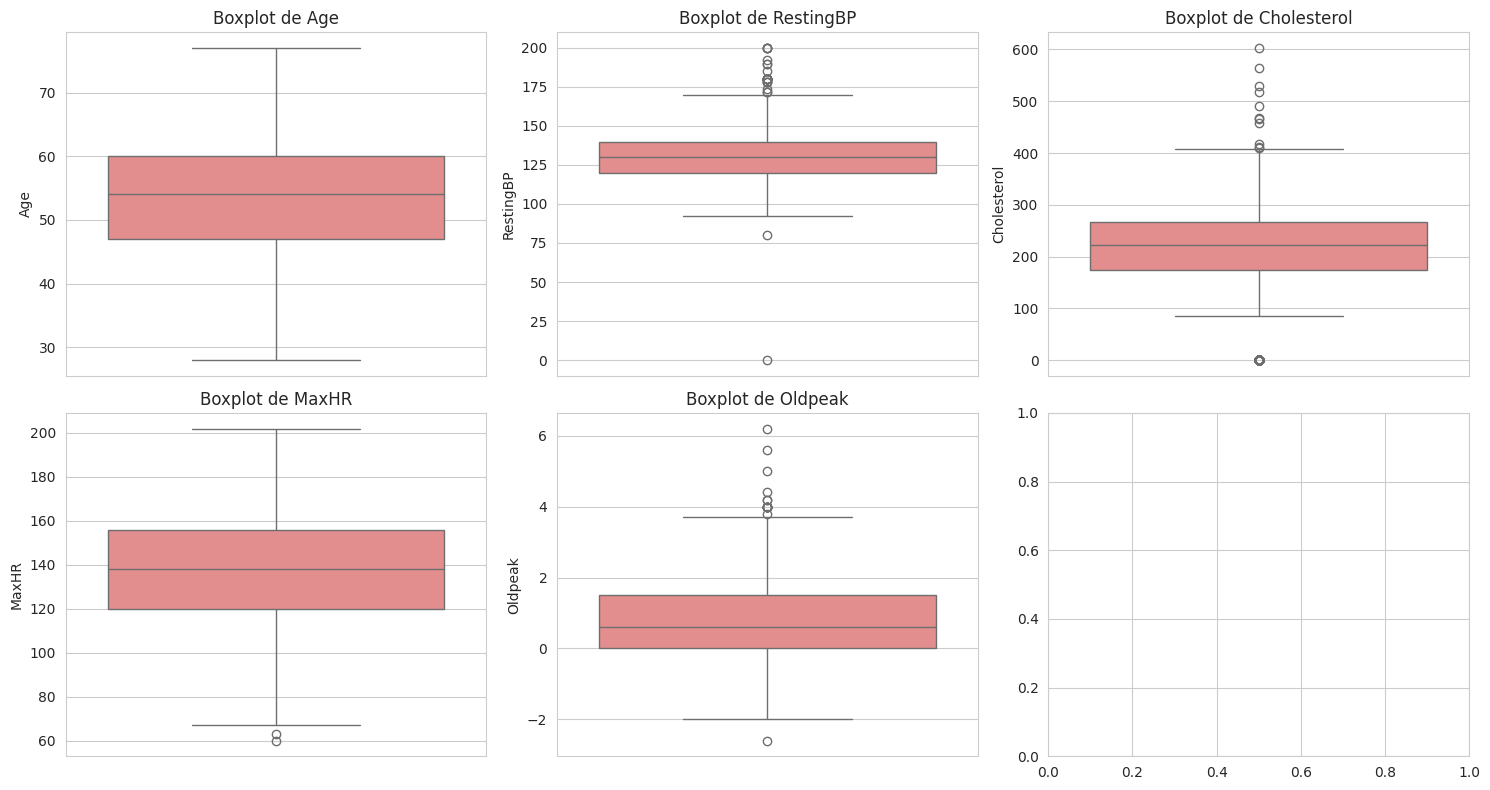

In [6]:
# Cellule 5: Analyse univariée - Variables numériques
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution de {col}', fontsize=12)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# Boxplots pour détecter les outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)

plt.tight_layout()
plt.show()

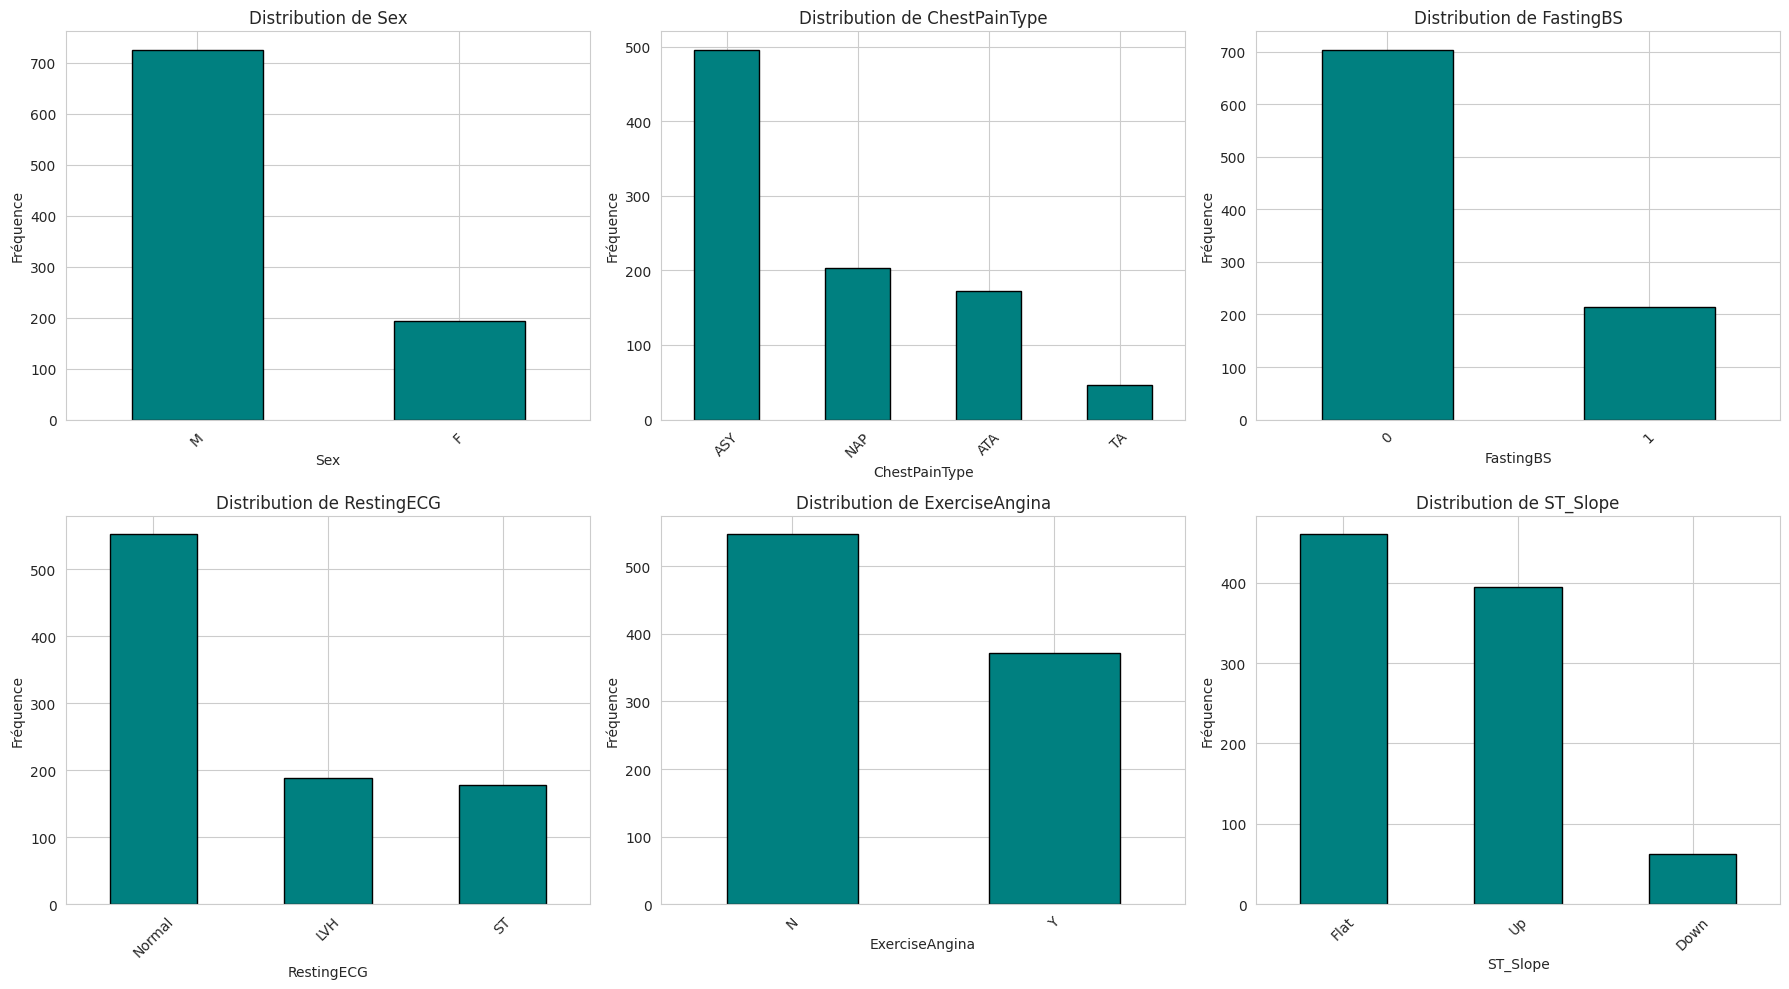

In [7]:
# Cellule 6: Analyse univariée - Variables catégorielles
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'Distribution de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

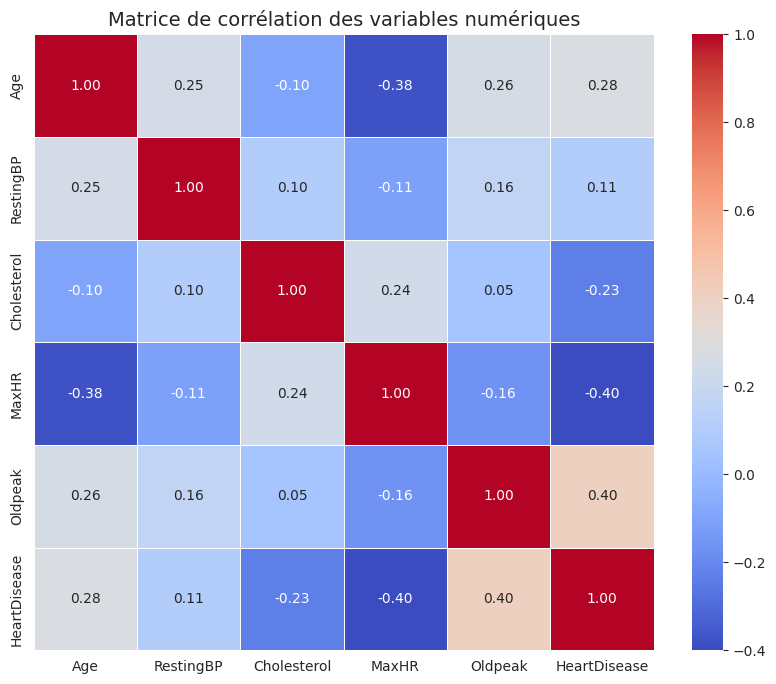

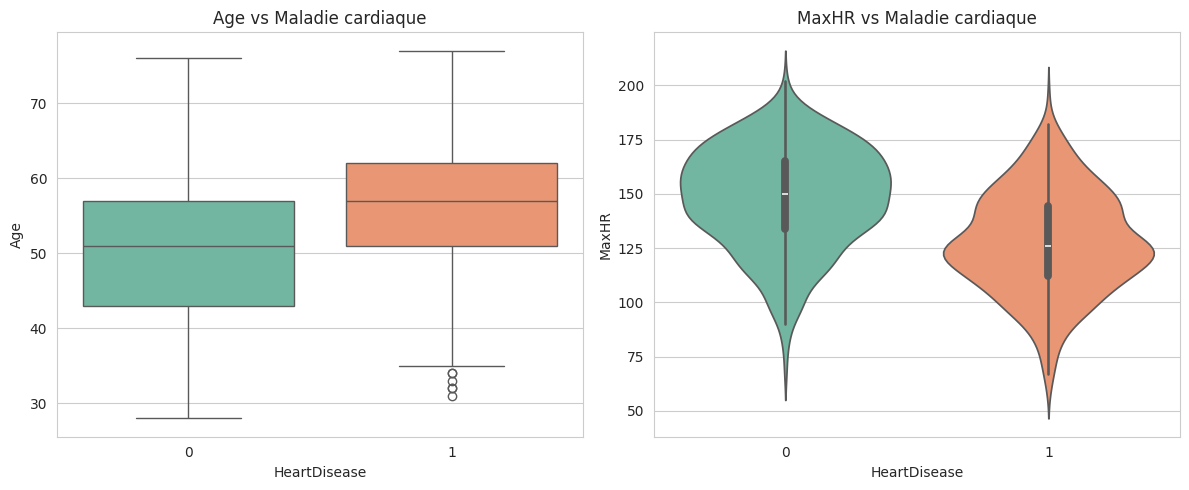

In [8]:
# Cellule 7: Analyse bivariée - Corrélation entre variables numériques
# Matrice de corrélation
corr_matrix = df[numeric_cols + ['HeartDisease']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.show()

# Relation entre Age et HeartDisease
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='HeartDisease', y='Age', palette='Set2')
plt.title('Age vs Maladie cardiaque')

plt.subplot(1, 2, 2)
sns.violinplot(data=df, x='HeartDisease', y='MaxHR', palette='Set2')
plt.title('MaxHR vs Maladie cardiaque')

plt.tight_layout()
plt.show()

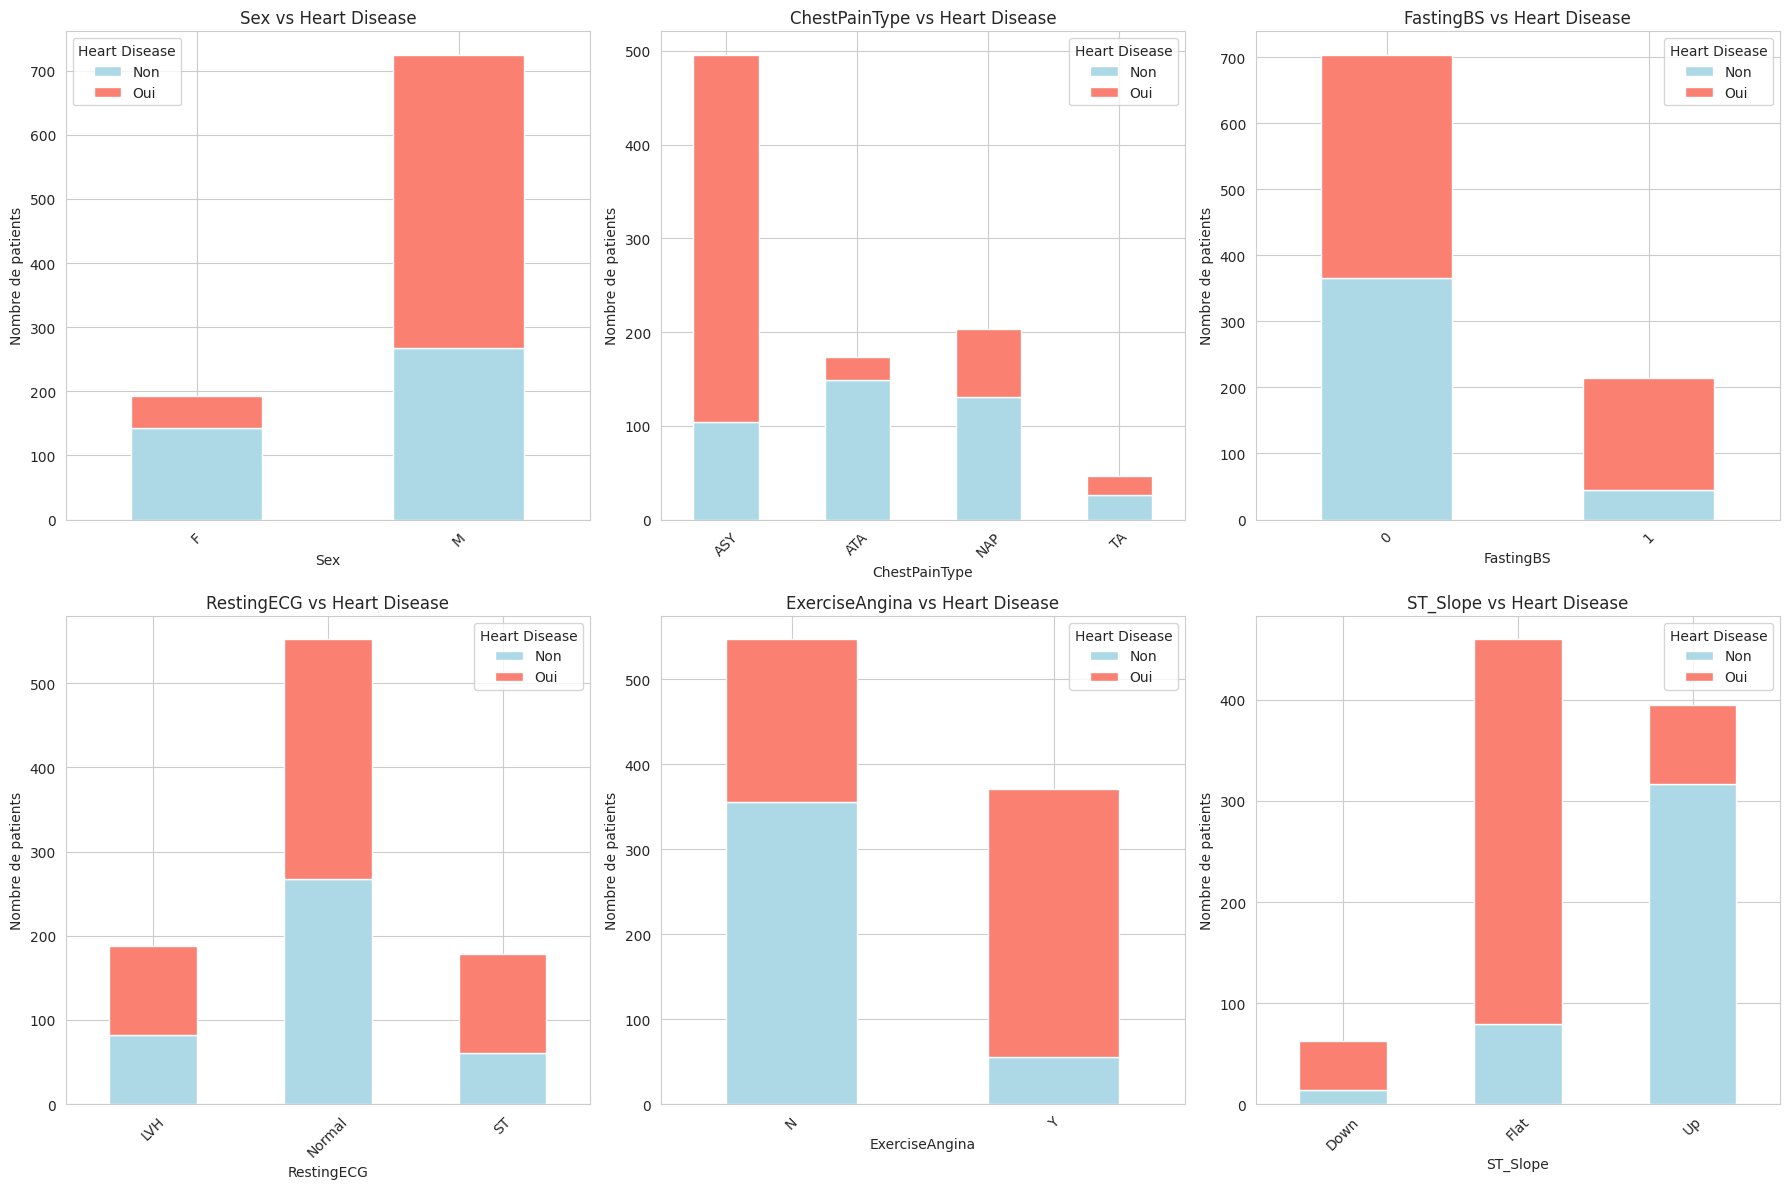

In [9]:
# Cellule 8: Analyse bivariée - Variables catégorielles vs HeartDisease
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['HeartDisease']).plot(kind='bar', stacked=True, ax=axes[i], color=['lightblue', 'salmon'])
    axes[i].set_title(f'{col} vs Heart Disease', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre de patients')
    axes[i].legend(title='Heart Disease', labels=['Non', 'Oui'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Cellule 9: Détection des outliers avec IQR
print("=== Détection des outliers (méthode IQR) ===")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({(len(outliers)/len(df))*100:.2f}%)")

=== Détection des outliers (méthode IQR) ===
Age: 0 outliers (0.00%)
RestingBP: 28 outliers (3.05%)
Cholesterol: 183 outliers (19.93%)
MaxHR: 2 outliers (0.22%)
Oldpeak: 16 outliers (1.74%)


In [11]:
# Cellule 10: Résumé de l'EDA
print("=== RÉSUMÉ DE L'EDA ===")
print(f"1. Shape du dataset: {df.shape}")
print(f"2. Variables: {list(df.columns)}")
print(f"3. Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"4. Doublons: {df.duplicated().sum()}")
print(f"5. Déséquilibre des classes: {df['HeartDisease'].value_counts().to_dict()}")
print("\nInsights clés:")
print("- Age, MaxHR et Oldpeak semblent corrélés avec la maladie")
print("- ChestPainType 'ASY' est fortement associé aux maladies cardiaques")
print("- ExerciseAngina 'Y' augmente le risque")
print("- Des outliers présents dans Cholesterol (valeurs à 0) et RestingBP")

=== RÉSUMÉ DE L'EDA ===
1. Shape du dataset: (918, 12)
2. Variables: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
3. Valeurs manquantes: 0
4. Doublons: 0
5. Déséquilibre des classes: {1: 508, 0: 410}

Insights clés:
- Age, MaxHR et Oldpeak semblent corrélés avec la maladie
- ChestPainType 'ASY' est fortement associé aux maladies cardiaques
- ExerciseAngina 'Y' augmente le risque
- Des outliers présents dans Cholesterol (valeurs à 0) et RestingBP
